In [1]:
#   PART A – Q1 SUPERVISED
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

The dataset contains patient health records used to predict heart disease.  
It includes demographic, clinical, and diagnostic features.

In [3]:
df = pd.read_csv(r"D:\bits course\assignment 4\q1_heart_disease.csv")

df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


### Dataset Overview

- Total records: 800  
- Features include age, cholesterol, blood pressure, ECG, etc.  
- Target variable: heart_disease (0 = No, 1 = Yes)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   chest_pain_type  800 non-null    str    
 3   resting_bp       776 non-null    float64
 4   cholesterol      768 non-null    float64
 5   fasting_bs       800 non-null    int64  
 6   resting_ecg      800 non-null    str    
 7   max_hr           800 non-null    int64  
 8   exercise_angina  800 non-null    int64  
 9   oldpeak          800 non-null    float64
 10  st_slope         800 non-null    str    
 11  heart_disease    800 non-null    int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 75.1 KB


In [5]:
df.shape

(800, 12)

In [6]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol',
       'fasting_bs', 'resting_ecg', 'max_hr', 'exercise_angina', 'oldpeak',
       'st_slope', 'heart_disease'],
      dtype='str')

In [7]:
df.describe()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease
count,800.000000,800.000000,776.000000,768.000000,800.00000,800.000000,800.000000,800.000000,800.000000
mean,52.191250,0.665000,130.668814,245.622396,0.23250,149.145000,0.295000,0.925500,0.508750
std,12.862211,0.472286,16.408805,52.185464,0.42269,22.396394,0.456328,0.897612,0.500236
min,30.000000,0.000000,90.000000,120.000000,0.00000,76.000000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,120.000000,209.000000,0.00000,134.000000,0.000000,0.300000,0.000000
50%,53.000000,1.000000,130.000000,247.000000,0.00000,149.000000,0.000000,0.600000,1.000000
75%,63.000000,1.000000,142.000000,279.250000,0.00000,165.000000,1.000000,1.300000,1.000000
max,74.000000,1.000000,184.000000,420.000000,1.00000,202.000000,1.000000,5.700000,1.000000


In [9]:
df.isnull().sum()

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

### Missing Value Treatment

- Missing values found in cholesterol and resting_bp  
- Filled using mean values to maintain dataset size  

In [13]:
# filling null values with mean
df['cholesterol'].fillna(df['cholesterol'].mean(), inplace=True)
df['resting_bp'].fillna(df['resting_bp'].mean(), inplace=True)

C:\Users\shwet\AppData\Local\Temp\ipykernel_18548\1216245710.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['cholesterol'].fillna(df['cholesterol'].mean(), inplace=True)
C:\Users\shwet\AppData\Local\Temp\ipykernel_18548\1216245710.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through ch

0      142.0
1      163.0
2      128.0
3      114.0
4      149.0
       ...  
795    147.0
796    125.0
797    120.0
798    112.0
799    116.0
Name: resting_bp, Length: 800, dtype: float64

### Exploratory Data Analysis

- Distribution plots show spread of numerical features  
- Count plots show class balance  
- Relationship plots highlight key risk factors

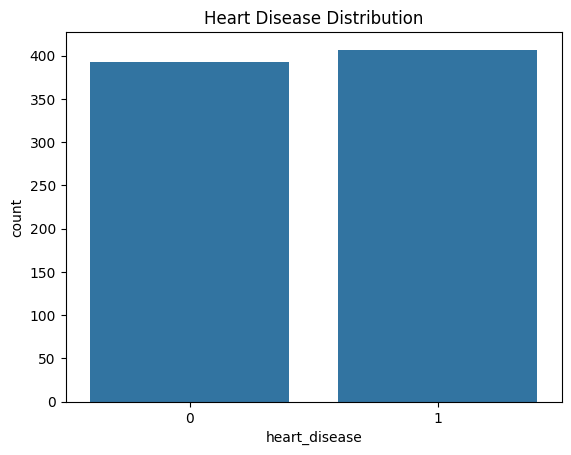

In [14]:
sns.countplot(x='heart_disease', data=df)
plt.title("Heart Disease Distribution")
plt.show()

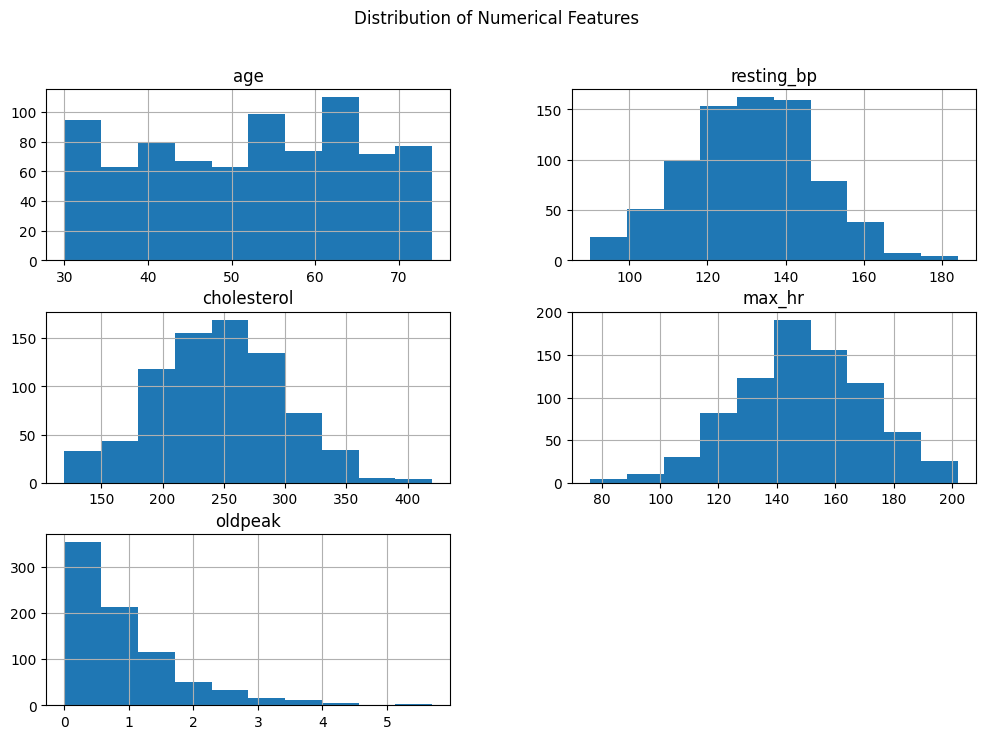

In [15]:
num_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']

df[num_cols].hist(figsize=(12,8))
plt.suptitle("Distribution of Numerical Features")
plt.show()

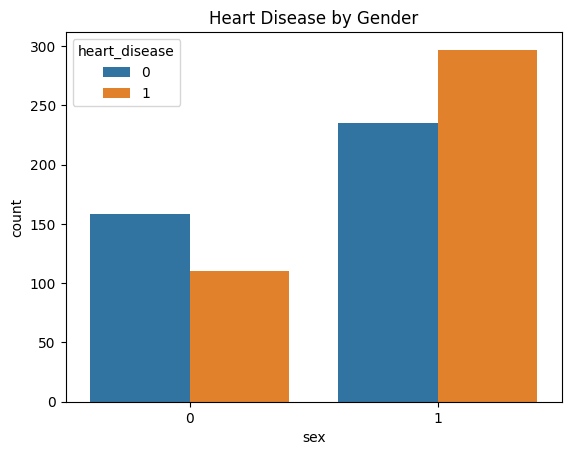

In [16]:
sns.countplot(x='sex', hue='heart_disease', data=df)
plt.title("Heart Disease by Gender")
plt.show()

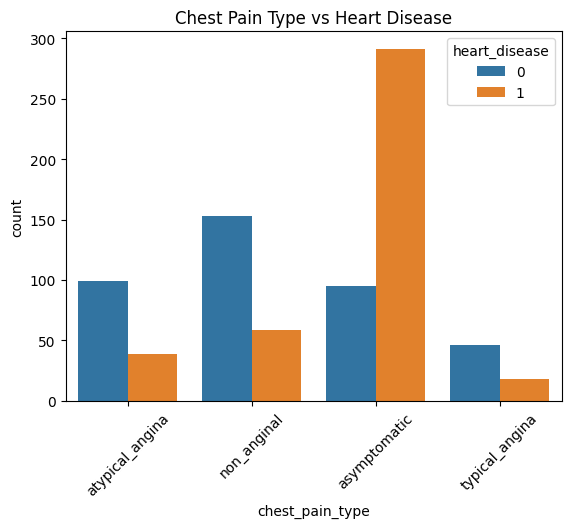

In [17]:
sns.countplot(x='chest_pain_type', hue='heart_disease', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.xticks(rotation=45)
plt.show()

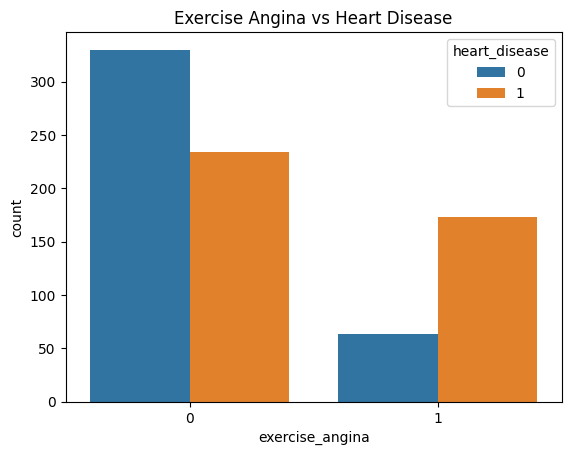

In [18]:
sns.countplot(x='exercise_angina', hue='heart_disease', data=df)
plt.title("Exercise Angina vs Heart Disease")
plt.show()

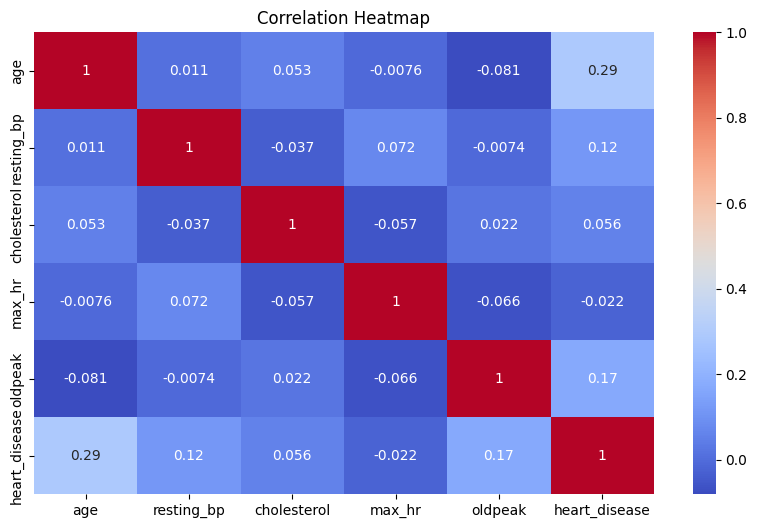

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols + ['heart_disease']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

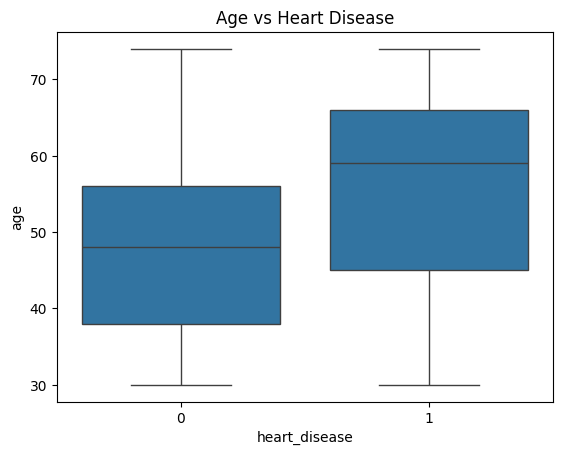

In [21]:
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

### Data Preprocessing

- One-hot encoding used for categorical variables  
- Standardization applied to numerical features  

In [22]:
# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

### Model Building

- Dataset split into training and testing sets  
- Classification models trained to predict heart disease  

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 


Decision Tree
Confusion Matrix:
 [[56 23]
 [25 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160



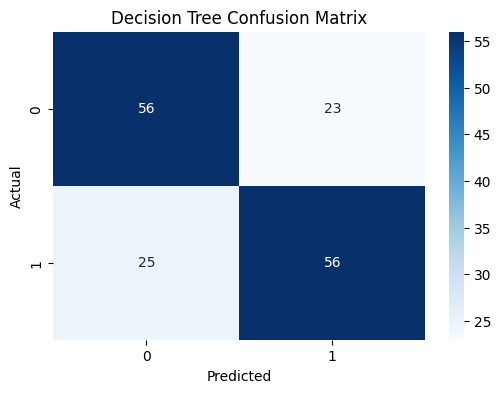


Random Forest
Confusion Matrix:
 [[61 18]
 [15 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



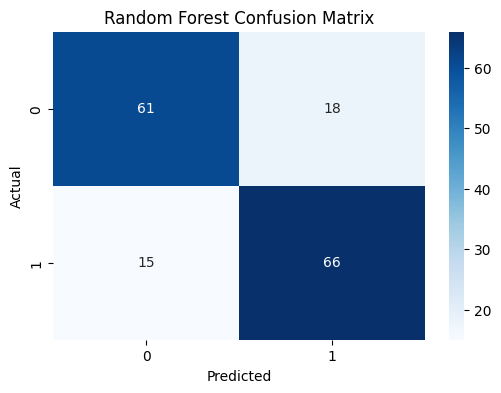


Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



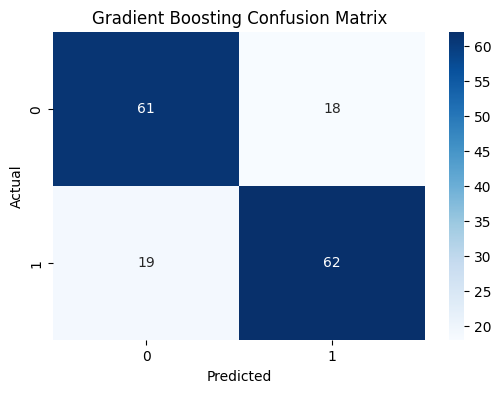

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


In [28]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Final Model Performance:\n")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Final Model Performance:

[[58 21]
 [16 65]]
              precision    recall  f1-score   support

           0       0.78      0.73      0.76        79
           1       0.76      0.80      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



### Conclusion

- Machine learning effectively predicts heart disease  
- Important features: age, chest pain, exercise angina  